# 02 - Pipeline

## Objetivo del notebook

Este notebook entrena y compara modelos multietiqueta para sugerir articulos candidatos del Convenio Europeo de Derechos Humanos a partir del texto de hechos.

El protocolo experimental se corrige para cumplir el criterio nuevo de evaluacion. La seleccion de hiperparametros se hace con `GridSearchCV` y validacion cruzada de 5 folds usando solo train. Test queda reservado para la evaluacion final.

## Como leerlo

1. **Preparacion** carga de splits y matriz multietiqueta.
2. **Pipelines** TF-IDF queda dentro del pipeline durante la validacion cruzada.
3. **GridSearchCV** cada modelo selecciona hiperparametros solo con train.
4. **Refit final** el mejor pipeline se reentrena con todo train.
5. **Evaluacion final** test se evalua solo al final.
6. **Artefactos** se guardan modelos, metricas, parametros y predicciones.

## Criterio metodologico

No se ajustan umbrales con validation en esta version. La decision evita usar un split externo para seleccionar configuraciones. Los modelos usan su regla de prediccion estandar despues de la busqueda con 5-fold CV sobre train.

La metrica principal de seleccion es macro-F1. Es adecuada porque el problema es multietiqueta y hay desbalanceo entre articulos.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_02_modeling_v2.png)

**Lectura del esquema.** La imagen resume el modelado. TF-IDF se usa como representacion comun dentro de cada pipeline. Se comparan LogReg OVR, SVM y SVD+MLP. La seleccion de hiperparametros se hace con `GridSearchCV` y 5 folds sobre train. Test queda reservado para la evaluacion final.


La tabla actua como indice tecnico del notebook. La columna **Seccion** permite localizar rapidamente donde se implementa cada paso.

| Seccion | Paso | Entrada | Transformacion | Salida | Nota |
|---|---|---|---|---|---|
| 1 | Carga desde SQLite | `cases.text_full` y `case_labels` | Union con la matriz multietiqueta `Y` | `frames['train']`, `frames['validation']`, `frames['test']` | Mantiene los splits separados. |
| 2.1 | Soporte por etiqueta | Splits oficiales | Conteo de positivos por articulo y split | Tabla de soporte | Anticipa desbalanceo. |
| 3.3 | Arrays | DataFrames por split | Texto y matriz binaria | `arrays` | Fuente unica para entrenamiento y evaluacion. |
| 3.4 | Pipelines | Texto bruto de train | TF-IDF dentro de pipeline | Estimadores completos | Evita leakage entre folds. |
| 3.6 | GridSearchCV | Solo train | 5-fold CV con macro-F1 | Mejor configuracion por modelo | Test no participa. |
| 3.6 | Refit final | Todo train | `refit=True` | Pipeline final por modelo | Modelo listo antes de test. |
| 3.6.5 | Evaluacion final | Test | Macro-F1, micro-F1 y Hamming | Tabla final | Comparativa final. |
| 4 | Auditoria de errores | Predicciones de test | FP/FN por articulo | Heatmaps y CSV | Analisis posterior a la evaluacion. |
| 5 | Curvas ROC/PR | Scores de test | Curvas micro-promediadas | Figura y CSV | No ajustan el modelo. |
| 10 | Persistencia | Modelos y metricas | Escritura en disco y SQLite | `artifacts/` | Alimenta notebooks posteriores. |

Validation se conserva como split informativo. No se usa para elegir hiperparametros, umbrales, arquitectura ni modelo final.


In [1]:
import json, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image as IPImage
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)

## 1. Datos de modelado

Se reconstruyen los splits oficiales desde SQLite. Esta seccion prepara la base comun del modelado: texto completo, identificadores de caso y columnas binarias por articulo.

In [2]:
pu.materialize_database(force=False)
frames = pu.train_validation_test_frames()
for split, df in frames.items():
    print(split, df.shape)
    display(df[['case_id','split','n_tokens'] + pu.ARTICLE_CODES].head(3))

train (9000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_train_000000,train,7014,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_train_000001,train,2788,0,0,0,1,0,0,0,0,1,1
2,ecthr_task_b_train_000002,train,1380,0,0,0,1,0,0,0,0,0,0


validation (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_validation_000000,validation,310,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_validation_000001,validation,1260,0,1,0,0,0,0,0,0,0,0
2,ecthr_task_b_validation_000002,validation,2116,0,1,0,1,0,0,0,0,0,0


test (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_test_000000,test,4774,0,0,0,0,0,0,1,0,0,0
1,ecthr_task_b_test_000001,test,1073,0,0,0,0,1,0,0,0,0,0
2,ecthr_task_b_test_000002,test,302,0,0,0,1,0,0,0,0,0,0


## 2. Formulacion One-vs-Rest

El problema se formula como diez decisiones binarias independientes: para cada articulo se aprende si esta presente o no en el caso. Esto evita convertir indebidamente una tarea multietiqueta en multiclase.

## 2.1 Conteo de casos por tipo de artículo y split


In [3]:
label_support = frames['train'][pu.ARTICLE_CODES].sum().rename('train_positives').rename_axis('article_code').reset_index()
label_support['validation_positives'] = frames['validation'][pu.ARTICLE_CODES].sum().values
label_support['test_positives'] = frames['test'][pu.ARTICLE_CODES].sum().values
display(label_support)

,article_code,train_positives,validation_positives,test_positives
0,2,623,75,76
1,3,1740,236,234
2,5,1623,219,196
3,6,5437,394,394
4,8,1056,153,188
5,9,81,9,11
6,10,441,64,106
7,11,162,39,43
8,14,444,34,32
9,P1-1,1558,168,155


## 3. Entrenamiento y comparacion


### 3.1 Imports, paths y artefactos

Se importan los estimadores y se centralizan las rutas de modelos. Todos los objetos entrenados se guardan en `artifacts/models/` para no reentrenar en cada ejecucion.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score, hamming_loss,
    jaccard_score, make_scorer, precision_recall_curve, roc_auc_score,
    roc_curve, auc
)
import joblib

CV_FOLDS = 5
SCORER = make_scorer(f1_score, average='macro', zero_division=0)
RUN_ID = 'notebook_cv5_logreg_default_threshold'

MODEL_PATHS = {
    'logreg_pipeline': pu.MODELS / 'notebook_cv5_logreg_pipeline.joblib',
    'svm_pipeline': pu.MODELS / 'notebook_cv5_svm_pipeline.joblib',
    'mlp_pipeline': pu.MODELS / 'notebook_cv5_svd_mlp_pipeline.joblib',
    'best_params': pu.MODELS / 'notebook_cv5_best_params.json',
}

### 3.2 Persistencia de predicciones

Esta version no ajusta umbrales con validation. Los modelos se evalúan con su regla estandar de prediccion.

La regresion logistica auditada guarda predicciones y scores para el notebook 04.


In [5]:
def save_run_and_predictions(run_id, model_name, config, metrics, case_ids, y_true, y_pred, scores):
    """Guarda una ejecucion experimental y sus predicciones en SQLite."""
    with pu.connect_db() as conn:
        conn.execute("DELETE FROM predictions WHERE run_id = ?", [run_id])
        conn.execute("DELETE FROM experiment_runs WHERE run_id = ?", [run_id])
        conn.execute(
            """
            INSERT INTO experiment_runs(run_id, stage, model_name, config_json, metrics_json, created_at, git_commit)
            VALUES (?, ?, ?, ?, ?, ?, ?)
            """,
            (
                run_id,
                'classification_notebook_cv5',
                model_name,
                json.dumps(config, sort_keys=True),
                json.dumps(metrics, sort_keys=True),
                datetime.now(timezone.utc).isoformat(),
                pu.git_commit(),
            ),
        )
        rows = []
        for idx, case_id in enumerate(case_ids):
            score_payload = None if scores is None else json.dumps([float(x) for x in scores[idx]])
            rows.append((run_id, case_id, json.dumps([int(x) for x in y_true[idx]]), json.dumps([int(x) for x in y_pred[idx]]), score_payload))
        conn.executemany(
            """
            INSERT INTO predictions(run_id, case_id, y_true_json, y_pred_json, scores_json)
            VALUES (?, ?, ?, ?, ?)
            """,
            rows,
        )
        conn.commit()

### 3.3 Preparacion de arrays

La validacion cruzada recibe texto bruto de train. TF-IDF se ajusta dentro de cada fold mediante `Pipeline`.

Esto evita leakage entre folds.


In [6]:
def load_split_arrays(frames, label_columns):
    """Convierte los DataFrames por split en arrays de modelado."""
    arrays = {}
    for split, df in frames.items():
        arrays[split] = {
            'case_ids': df['case_id'].tolist(),
            'texts': df['text_full'].tolist(),
            'y': df[label_columns].to_numpy(dtype=int),
        }
    return arrays

### 3.4 Pipelines y rejillas

Cada modelo usa `GridSearchCV` con 5 folds sobre train.

El vectorizador esta dentro del pipeline. SVD y scaler tambien quedan dentro del pipeline de la MLP.

La MLP se mantiene como comparacion secundaria. Usa una rejilla reducida por coste computacional.


In [7]:
def build_model_specs():
    """Define pipelines y rejillas pequeñas para 5-fold CV."""
    logreg_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2), max_df=0.95, sublinear_tf=True,
            strip_accents='unicode', lowercase=True, dtype=np.float32
        )),
        ('clf', OneVsRestClassifier(
            LogisticRegression(max_iter=1000, solver='liblinear', random_state=pu.SEED)
        )),
    ])
    logreg_grid = {
        'tfidf__max_features': [30000, 60000],
        'tfidf__min_df': [2, 5],
        'clf__estimator__C': [0.5, 1.0, 2.0],
        'clf__estimator__class_weight': ['balanced'],
    }

    svm_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2), max_df=0.95, sublinear_tf=True,
            strip_accents='unicode', lowercase=True, dtype=np.float32
        )),
        ('clf', OneVsRestClassifier(
            LinearSVC(max_iter=5000, random_state=pu.SEED)
        )),
    ])
    svm_grid = {
        'tfidf__max_features': [30000, 60000],
        'tfidf__min_df': [2, 5],
        'clf__estimator__C': [0.5, 1.0, 2.0],
        'clf__estimator__class_weight': ['balanced'],
    }

    mlp_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
            strip_accents='unicode', lowercase=True, dtype=np.float32
        )),
        ('svd', TruncatedSVD(random_state=pu.SEED)),
        ('scaler', StandardScaler()),
        ('clf', OneVsRestClassifier(
            MLPClassifier(
                activation='relu', learning_rate_init=1e-3, max_iter=45,
                early_stopping=True, n_iter_no_change=5, batch_size=128,
                random_state=pu.SEED
            )
        )),
    ])
    mlp_grid = {
        'tfidf__max_features': [30000],
        'svd__n_components': [100, 300],
        'clf__estimator__hidden_layer_sizes': [(128,)],
        'clf__estimator__alpha': [0.0001, 0.001],
    }

    return {
        'tfidf_logreg_cv5': {
            'pipeline': logreg_pipeline,
            'param_grid': logreg_grid,
            'path': MODEL_PATHS['logreg_pipeline'],
        },
        'tfidf_linear_svm_cv5': {
            'pipeline': svm_pipeline,
            'param_grid': svm_grid,
            'path': MODEL_PATHS['svm_pipeline'],
        },
        'tfidf_svd_mlp_cv5': {
            'pipeline': mlp_pipeline,
            'param_grid': mlp_grid,
            'path': MODEL_PATHS['mlp_pipeline'],
        },
    }


def fit_grid_search(model_name, spec, x_train_texts, y_train):
    """Ejecuta GridSearchCV con 5 folds usando solo train."""
    search = GridSearchCV(
        estimator=spec['pipeline'],
        param_grid=spec['param_grid'],
        scoring=SCORER,
        cv=CV_FOLDS,
        refit=True,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    search.fit(x_train_texts, y_train)
    joblib.dump(search.best_estimator_, spec['path'])
    return search


def load_or_fit_grid_searches(model_specs, arrays, retrain=False):
    """Carga pipelines finales o ejecuta las busquedas si hace falta."""
    searches = {}
    final_models = {}
    cv_rows = []
    best_params = {}

    for model_name, spec in model_specs.items():
        needs_fit = retrain or not spec['path'].exists()
        if needs_fit:
            search = fit_grid_search(model_name, spec, arrays['train']['texts'], arrays['train']['y'])
            searches[model_name] = search
            final_models[model_name] = search.best_estimator_
            cv_result = pd.DataFrame(search.cv_results_)
            cv_result.insert(0, 'model', model_name)
            cv_rows.append(cv_result)
            best_params[model_name] = {
                'best_params': search.best_params_,
                'best_cv_macro_f1': float(search.best_score_),
                'cv_folds': CV_FOLDS,
                'selection_data': 'train',
                'refit_data': 'train',
            }
        else:
            final_models[model_name] = joblib.load(spec['path'])
            best_params[model_name] = {
                'best_params': None,
                'best_cv_macro_f1': None,
                'cv_folds': CV_FOLDS,
                'selection_data': 'train',
                'refit_data': 'train',
                'loaded_from_disk': str(spec['path']),
            }

    if cv_rows:
        cv_results = pd.concat(cv_rows, ignore_index=True)
        cv_results.to_csv(pu.METRICS / 'cv_gridsearch_results.csv', index=False)
    elif (pu.METRICS / 'cv_gridsearch_results.csv').exists():
        cv_results = pd.read_csv(pu.METRICS / 'cv_gridsearch_results.csv')
    else:
        cv_results = pd.DataFrame()

    MODEL_PATHS['best_params'].write_text(json.dumps(best_params, indent=2, sort_keys=True, default=str), encoding='utf-8')
    (pu.METRICS / 'best_params_by_model.json').write_text(json.dumps(best_params, indent=2, sort_keys=True, default=str), encoding='utf-8')
    return final_models, searches, cv_results, best_params

### 3.5 Funciones auxiliares modulares



#### 3.5.1 Scores y reportes por modelo

Estas funciones convierten salidas de modelos en scores comparables y muestran una tabla corta con macro-F1 y micro-F1 junto a una figura de entrenamiento/validacion/test.

In [8]:
def decision_scores(model, texts):
    """Devuelve scores continuos para curvas y ranking."""
    if hasattr(model, 'predict_proba'):
        return pu.as_probability_matrix(model.predict_proba(texts))
    if hasattr(model, 'decision_function'):
        return np.asarray(model.decision_function(texts), dtype=float)
    return None


def display_model_report(model_name, metrics_df):
    """Muestra tabla corta de train, validation y test."""
    display(metrics_df[['model', 'split', 'macro_f1', 'micro_f1', 'hamming_loss']])
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(data=metrics_df, x='split', y='macro_f1', marker='o', ax=ax, label='macro_f1')
    sns.lineplot(data=metrics_df, x='split', y='micro_f1', marker='o', ax=ax, label='micro_f1')
    ax.set_title(f'{model_name}: diagnostico por split')
    ax.set_xlabel('Split')
    ax.set_ylabel('F1')
    ax.set_ylim(0, 1)
    fig.tight_layout()
    safe_name = model_name.replace('/', '_').replace(' ', '_')
    report_path = pu.FIGURES / f'training_report_{safe_name}.png'
    fig.savefig(report_path, dpi=180)
    plt.close(fig)
    display(IPImage(filename=str(report_path)))

#### 3.5.2 Metricas completas guardadas en CSV

El notebook no muestra toda la batería de métricas, estas se calculan y se guardan en csvs. 

In [9]:
def score_metrics(y_true, scores):
    """Metricas de ranking multietiqueta calculadas sobre scores continuos."""
    return {
        'roc_auc_macro': float(roc_auc_score(y_true, scores, average='macro')),
        'roc_auc_micro': float(roc_auc_score(y_true, scores, average='micro')),
        'pr_auc_macro': float(average_precision_score(y_true, scores, average='macro')),
        'pr_auc_micro': float(average_precision_score(y_true, scores, average='micro')),
    }


def extended_metric_table(y_true, y_pred, split, model_name, scores=None):
    """Une F1/Hamming con metricas adicionales de multilabel y ranking."""
    row = pu.metric_table(y_true, y_pred, split, model_name)
    row.update({
        'subset_accuracy': float(accuracy_score(y_true, y_pred)),
        'jaccard_macro': float(jaccard_score(y_true, y_pred, average='macro', zero_division=0)),
        'jaccard_micro': float(jaccard_score(y_true, y_pred, average='micro', zero_division=0)),
    })
    if scores is not None:
        row.update(score_metrics(y_true, scores))
    else:
        row.update({
            'roc_auc_macro': np.nan,
            'roc_auc_micro': np.nan,
            'pr_auc_macro': np.nan,
            'pr_auc_micro': np.nan,
        })
    return row


def extended_metrics_for_model(arrays, predictions, model_name, scores_by_split=None, splits=pu.SPLIT_ORDER):
    """Tabla completa por split para modelos con o sin scores."""
    return pd.DataFrame([
        extended_metric_table(
            arrays[split]['y'],
            predictions[split],
            split,
            model_name,
            None if scores_by_split is None else scores_by_split[split],
        )
        for split in splits
    ])

#### 3.5.3 Curvas ROC y Precision-Recall

La funcion devuelve una figura Matplotlib y una tabla resumen. 

In [10]:
def plot_roc_pr_curves(y_true, scores_by_model, split='test'):
    """Dibuja curvas ROC y Precision-Recall micro-promediadas por modelo."""
    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(scores_by_model)))
    for color, (model_name, scores) in zip(colors, scores_by_model.items()):
        fpr, tpr, _ = roc_curve(y_true.ravel(), scores.ravel())
        precision, recall, _ = precision_recall_curve(y_true.ravel(), scores.ravel())
        roc_value = auc(fpr, tpr)
        pr_value = auc(recall, precision)
        axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} | AUC={roc_value:.3f}')
        axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{model_name} | AP={pr_value:.3f}')
        rows.append({'model': model_name, 'split': split, 'roc_auc_micro_curve': float(roc_value), 'pr_auc_micro_curve': float(pr_value)})
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='0.55', linewidth=1.2, label='Azar')
    axes[0].set_title(f'Curva ROC micro - {split}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.02)
    axes[1].set_title(f'Curva Precision-Recall micro - {split}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.02)
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig, pd.DataFrame(rows)

#### 3.5.4 Persistencia y auditoria de errores

Estas funciones guardan predicciones por caso y construyen la matriz TP/FP/FN/TN por articulo. El CSV completo queda guardado y se muestran heatmaps de estas métricas.

In [11]:
def store_audited_predictions(arrays, model, metrics_rows):
    """Guarda predicciones de la regresion logistica con protocolo CV5."""
    all_case_ids, all_true, all_pred, all_scores = [], [], [], []
    for split in pu.SPLIT_ORDER:
        texts = arrays[split]['texts']
        pred = model.predict(texts)
        scores = decision_scores(model, texts)
        all_case_ids.extend(arrays[split]['case_ids'])
        all_true.append(arrays[split]['y'])
        all_pred.append(np.asarray(pred, dtype=int))
        all_scores.append(scores)

    save_run_and_predictions(
        run_id=RUN_ID,
        model_name='tfidf_logreg_cv5_default_threshold',
        config={
            'protocol': 'GridSearchCV cv=5 sobre train y refit final sobre todo train',
            'selection_metric': 'macro-F1',
            'threshold_policy': 'regla estandar del clasificador sin ajuste externo',
        },
        metrics=metrics_rows,
        case_ids=all_case_ids,
        y_true=np.vstack(all_true),
        y_pred=np.vstack(all_pred),
        scores=np.vstack(all_scores),
    )


def correspondence_table(y_true, y_pred, model_name, split='test'):
    """Matriz de correspondencia multietiqueta: TN/FP/FN/TP por articulo."""
    rows = []
    for col, article_code in enumerate(pu.ARTICLE_CODES):
        true_col = y_true[:, col]
        pred_col = y_pred[:, col]
        rows.append({
            'model': model_name,
            'split': split,
            'article_code': article_code,
            'tn': int(((true_col == 0) & (pred_col == 0)).sum()),
            'fp': int(((true_col == 0) & (pred_col == 1)).sum()),
            'fn': int(((true_col == 1) & (pred_col == 0)).sum()),
            'tp': int(((true_col == 1) & (pred_col == 1)).sum()),
        })
    return pd.DataFrame(rows)

### 3.6 Pipeline con seleccion por 5-fold CV

Primero se preparan los arrays.

Despues cada modelo ejecuta `GridSearchCV` con 5 folds sobre train.

El mejor pipeline queda reentrenado con todo train por `refit=True`.


In [12]:
RETRAIN_MODELS = True
arrays = load_split_arrays(frames, pu.ARTICLE_CODES)
model_results = {}
model_predictions = {}
model_scores = {}

print({split: (len(arrays[split]['texts']), arrays[split]['y'].shape) for split in pu.SPLIT_ORDER})

{'train': (9000, (9000, 10)), 'validation': (1000, (1000, 10)), 'test': (1000, (1000, 10))}


#### 3.6.1 Modelo 1: baseline de articulo frecuente

No aprende texto: predice siempre el articulo mas frecuente observado en train. Su utilidad no es competir, sino fijar un suelo experimental interpretable.

Articulo constante predicho: 6


,model,split,macro_f1,micro_f1,hamming_loss
0,baseline_most_frequent_label,train,0.075320,0.490593,0.125456
1,baseline_most_frequent_label,validation,0.056528,0.329569,0.160300
2,baseline_most_frequent_label,test,0.056528,0.323614,0.164700


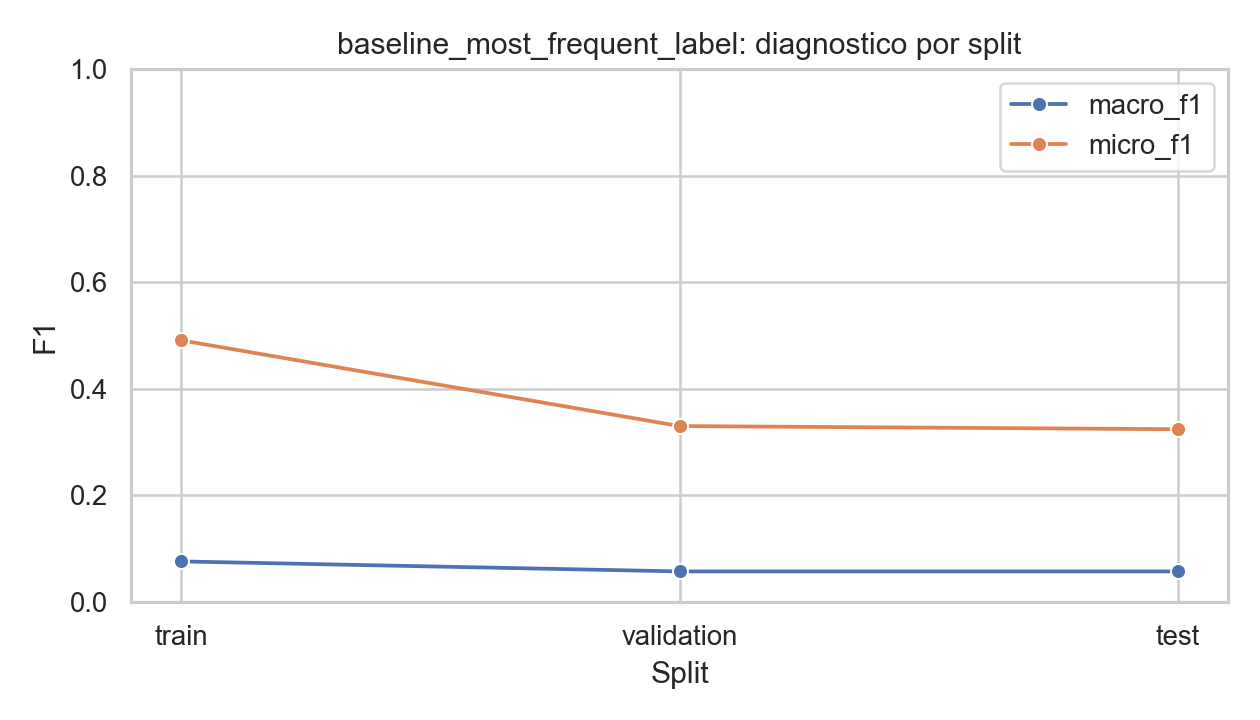

In [13]:
baseline_name = 'baseline_most_frequent_label'
most_frequent = int(np.argmax(arrays['train']['y'].sum(axis=0)))
most_frequent_article = pu.ARTICLE_CODES[most_frequent]

baseline_pred = {}
for split in pu.SPLIT_ORDER:
    pred = np.zeros_like(arrays[split]['y'])
    pred[:, most_frequent] = 1
    baseline_pred[split] = pred

baseline_metrics = extended_metrics_for_model(arrays, baseline_pred, baseline_name)
model_results[baseline_name] = baseline_metrics
model_predictions[baseline_name] = baseline_pred
print(f'Articulo constante predicho: {most_frequent_article}')
display_model_report(baseline_name, baseline_metrics)

#### 3.6.2 Modelo 2 TF-IDF + regresion logistica One-vs-Rest

La regresion logistica usa `GridSearchCV` con 5 folds sobre train.

No usa validation ni test para seleccionar hiperparametros.


In [14]:
model_specs = build_model_specs()
final_models, searches, cv_results, best_params = load_or_fit_grid_searches(
    model_specs,
    arrays,
    retrain=RETRAIN_MODELS,
)

if not cv_results.empty:
    cv_summary = (
        cv_results.sort_values(['model', 'rank_test_score'])
        .groupby('model')
        .head(3)
        [['model', 'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'params']]
    )
    display(cv_summary)

display(pd.DataFrame([
    {
        'model': model_name,
        'best_cv_macro_f1': payload.get('best_cv_macro_f1'),
        'cv_folds': payload.get('cv_folds'),
        'selection_data': payload.get('selection_data'),
    }
    for model_name, payload in best_params.items()
]))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


,model,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
12,tfidf_linear_svm_cv5,1,0.733333,0.041915,0.968194,"{'clf__estimator__C': 0.5, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 30000, 'tfidf__min_df': 2}"
13,tfidf_linear_svm_cv5,2,0.732953,0.042100,0.968165,"{'clf__estimator__C': 0.5, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 30000, 'tfidf__min_df': 5}"
14,tfidf_linear_svm_cv5,3,0.732857,0.043542,0.974816,"{'clf__estimator__C': 0.5, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 60000, 'tfidf__min_df': 2}"
11,tfidf_logreg_cv5,1,0.726208,0.036127,0.913823,"{'clf__estimator__C': 2.0, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 60000, 'tfidf__min_df': 5}"
10,tfidf_logreg_cv5,2,0.724990,0.035967,0.913927,"{'clf__estimator__C': 2.0, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 60000, 'tfidf__min_df': 2}"
9,tfidf_logreg_cv5,3,0.724742,0.034324,0.901564,"{'clf__estimator__C': 2.0, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 30000, 'tfidf__min_df': 5}"
25,tfidf_svd_mlp_cv5,1,0.698336,0.046931,0.886851,"{'clf__estimator__alpha': 0.0001, 'clf__estimator__hidden_layer_sizes': (128,), 'svd__n_components': 300, 'tfidf__max_features': 30000}"
27,tfidf_svd_mlp_cv5,2,0.698058,0.048617,0.885526,"{'clf__estimator__alpha': 0.001, 'clf__estimator__hidden_layer_sizes': (128,), 'svd__n_components': 300, 'tfidf__max_features': 30000}"
26,tfidf_svd_mlp_cv5,3,0.615627,0.031484,0.738202,"{'clf__estimator__alpha': 0.001, 'clf__estimator__hidden_layer_sizes': (128,), 'svd__n_components': 100, 'tfidf__max_features': 30000}"


,model,best_cv_macro_f1,cv_folds,selection_data
0,tfidf_logreg_cv5,0.726208,5,train
1,tfidf_linear_svm_cv5,0.733333,5,train
2,tfidf_svd_mlp_cv5,0.698336,5,train


#### 3.6.3 Modelo 3 TF-IDF + SVM lineal One-vs-Rest

La SVM lineal tambien usa `GridSearchCV` con 5 folds sobre train.

Es un comparador fuerte para texto disperso.


In [15]:
print('Mejores parametros de SVM')
display(pd.DataFrame([best_params['tfidf_linear_svm_cv5']['best_params']]))

Mejores parametros de SVM


,clf__estimator__C,clf__estimator__class_weight,tfidf__max_features,tfidf__min_df
0,0.5,balanced,30000,2


#### 3.6.4 Modelo 4 TF-IDF + SVD + MLP

La MLP se mantiene como comparacion secundaria.

Tambien usa `GridSearchCV` con 5 folds sobre train.

La rejilla es reducida para controlar el tiempo de ejecucion.


In [16]:
print('Mejores parametros de MLP')
display(pd.DataFrame([best_params['tfidf_svd_mlp_cv5']['best_params']]))

Mejores parametros de MLP


,clf__estimator__alpha,clf__estimator__hidden_layer_sizes,svd__n_components,tfidf__max_features
0,0.0001,"(128,)",300,30000


#### 3.6.5 Evaluacion final en test

Los modelos ya estan fijados antes de mirar test.

Validation se muestra solo como diagnostico. No decide el modelo final.

La comparativa final se guarda con resultados de test.


,model,split,macro_f1,micro_f1,hamming_loss
0,tfidf_logreg_cv5,train,0.908234,0.923161,0.023322
1,tfidf_logreg_cv5,validation,0.730349,0.774965,0.064000
2,tfidf_logreg_cv5,test,0.736296,0.759874,0.068700


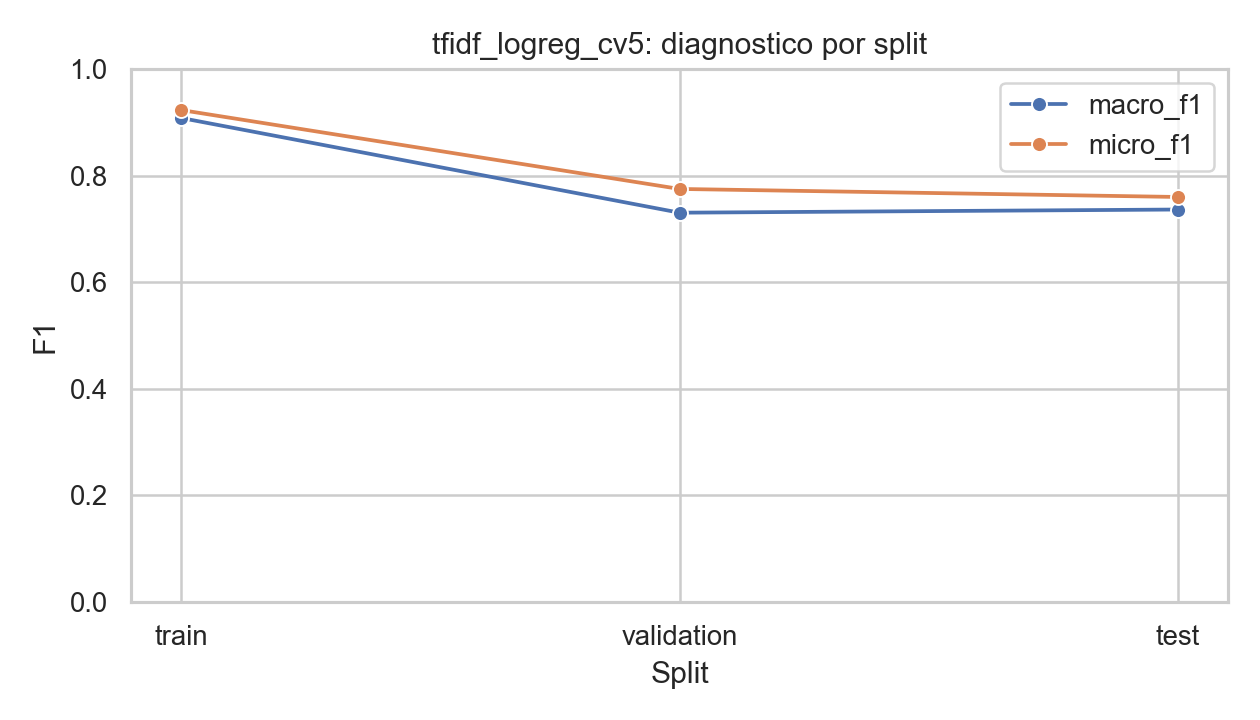

,model,split,macro_f1,micro_f1,hamming_loss
0,tfidf_linear_svm_cv5,train,0.964804,0.966613,0.009922
1,tfidf_linear_svm_cv5,validation,0.731935,0.790952,0.057300
2,tfidf_linear_svm_cv5,test,0.748724,0.777172,0.061300


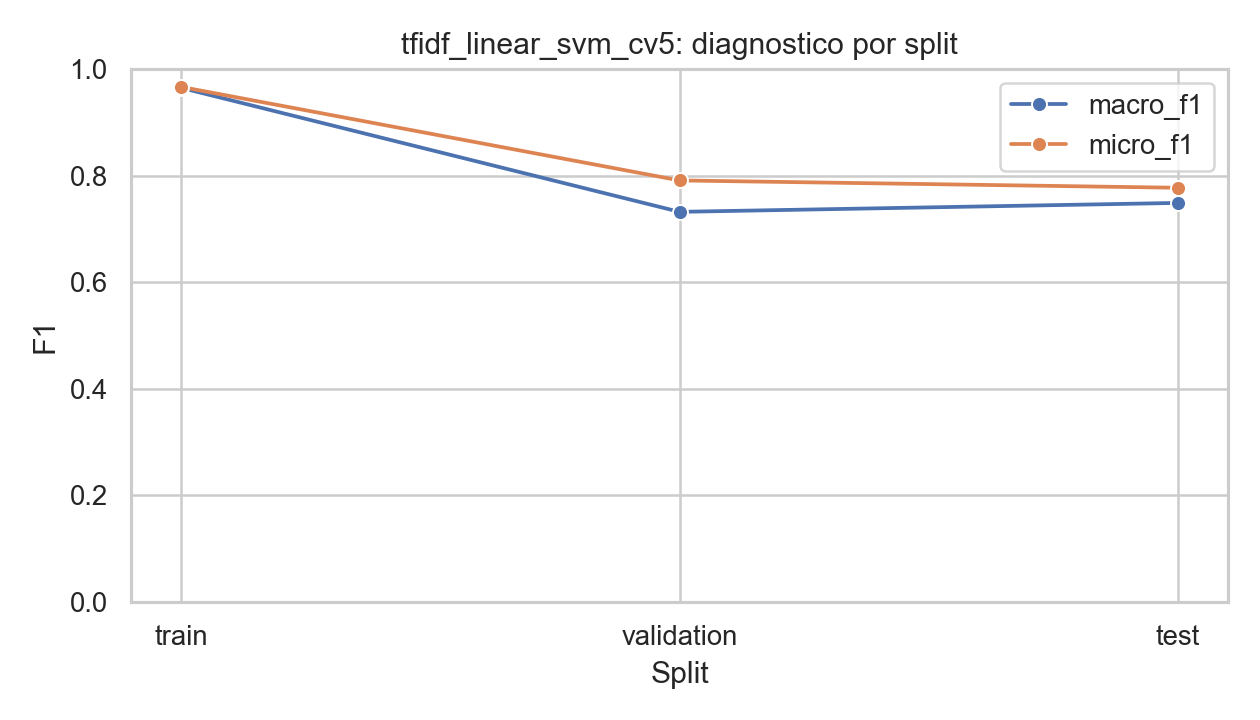

,model,split,macro_f1,micro_f1,hamming_loss
0,tfidf_svd_mlp_cv5,train,0.884099,0.943536,0.016144
1,tfidf_svd_mlp_cv5,validation,0.697704,0.776075,0.059900
2,tfidf_svd_mlp_cv5,test,0.690359,0.767390,0.062200


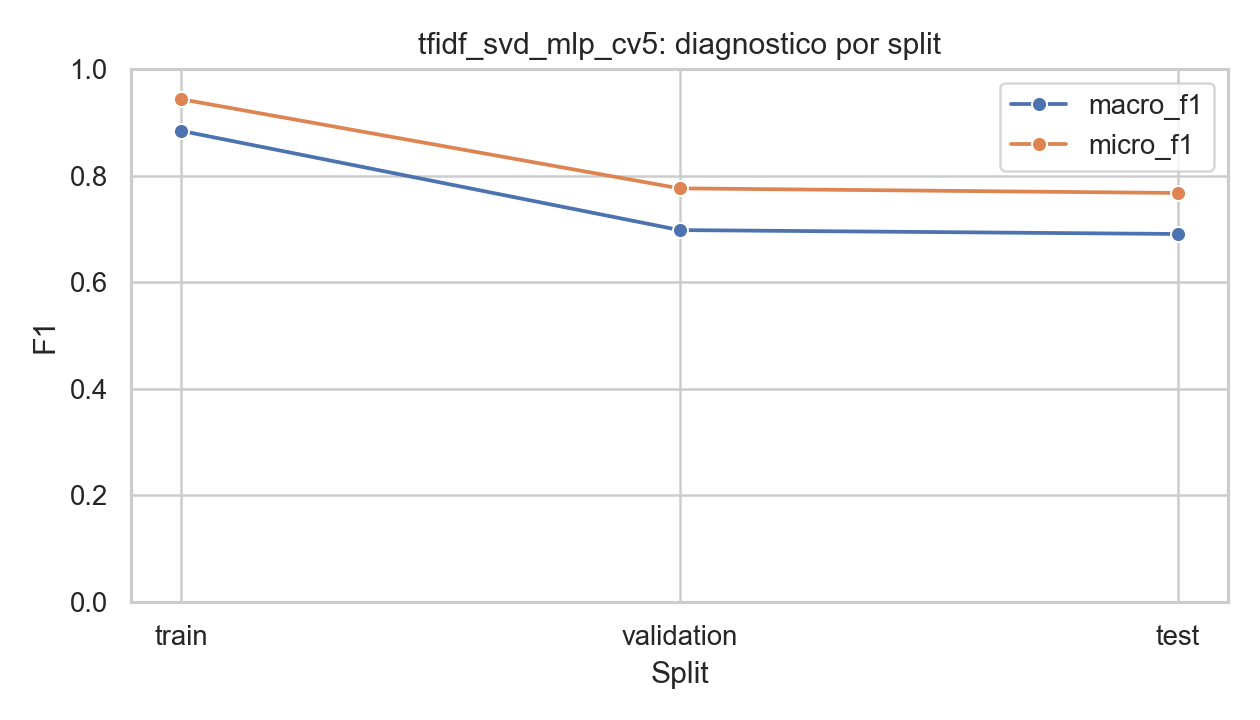

,model,n_cases,macro_f1,micro_f1,hamming_loss
8,tfidf_linear_svm_cv5,1000,0.748724,0.777172,0.0613
5,tfidf_logreg_cv5,1000,0.736296,0.759874,0.0687
11,tfidf_svd_mlp_cv5,1000,0.690359,0.767390,0.0622
2,baseline_most_frequent_label,1000,0.056528,0.323614,0.1647


Artefactos guardados
- logreg_pipeline: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifacts\models\notebook_cv5_logreg_pipeline.joblib
- svm_pipeline: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifacts\models\notebook_cv5_svm_pipeline.joblib
- mlp_pipeline: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifacts\models\notebook_cv5_svd_mlp_pipeline.joblib
- best_params: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifacts\models\notebook_cv5_best_params.json
- cv_results: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifacts\metrics\cv_gridsearch_results.csv
- test_comparison: C:\Users\mauro\OneDrive\Escritorio\All\IA_DEFINITIVO\Año3\Semestre2\Aprendizaje_Avanzado\proyecto final\artifact

In [17]:
for model_name, model in final_models.items():
    preds_by_split = {}
    scores_by_split = {}
    for split in pu.SPLIT_ORDER:
        texts = arrays[split]['texts']
        preds_by_split[split] = np.asarray(model.predict(texts), dtype=int)
        scores_by_split[split] = decision_scores(model, texts)
    model_predictions[model_name] = preds_by_split
    model_scores[model_name] = scores_by_split
    metrics_df = extended_metrics_for_model(arrays, preds_by_split, model_name, scores_by_split)
    model_results[model_name] = metrics_df
    display_model_report(model_name, metrics_df)

comparison = pd.concat(model_results.values(), ignore_index=True)
comparison.to_csv(pu.METRICS / 'classification_model_comparison.csv', index=False)

test_comparison_cv = comparison[comparison['split'] == 'test'].sort_values('macro_f1', ascending=False).copy()
test_comparison_cv.to_csv(pu.METRICS / 'test_model_comparison_cv.csv', index=False)
test_comparison_cv.to_csv(pu.METRICS / 'paper_classification_table.csv', index=False)

store_audited_predictions(
    arrays,
    final_models['tfidf_logreg_cv5'],
    comparison[comparison['model'] == 'tfidf_logreg_cv5'].to_dict(orient='records'),
)

display(test_comparison_cv[['model', 'n_cases', 'macro_f1', 'micro_f1', 'hamming_loss']])
print('Artefactos guardados')
for name, path_obj in MODEL_PATHS.items():
    print(f'- {name}: {path_obj}')
print(f'- cv_results: {pu.METRICS / "cv_gridsearch_results.csv"}')
print(f'- test_comparison: {pu.METRICS / "test_model_comparison_cv.csv"}')

## 3.7 Lectura de resultados

La comparativa final usa test.

No se usa test para elegir hiperparametros, umbrales, arquitectura ni vectorizador.

La tabla de test resume el rendimiento final de modelos ya fijados.


In [18]:
cv_best = pd.DataFrame([
    {
        'model': model_name,
        'best_cv_macro_f1': payload.get('best_cv_macro_f1'),
        'best_params': payload.get('best_params'),
    }
    for model_name, payload in best_params.items()
])
final_test = test_comparison_cv[['model', 'macro_f1', 'micro_f1', 'hamming_loss']].copy()

display(cv_best)
display(final_test)

,model,best_cv_macro_f1,best_params
0,tfidf_logreg_cv5,0.726208,"{'clf__estimator__C': 2.0, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 60000, 'tfidf__min_df': 5}"
1,tfidf_linear_svm_cv5,0.733333,"{'clf__estimator__C': 0.5, 'clf__estimator__class_weight': 'balanced', 'tfidf__max_features': 30000, 'tfidf__min_df': 2}"
2,tfidf_svd_mlp_cv5,0.698336,"{'clf__estimator__alpha': 0.0001, 'clf__estimator__hidden_layer_sizes': (128,), 'svd__n_components': 300, 'tfidf__max_features': 30000}"


,model,macro_f1,micro_f1,hamming_loss
8,tfidf_linear_svm_cv5,0.748724,0.777172,0.0613
5,tfidf_logreg_cv5,0.736296,0.759874,0.0687
11,tfidf_svd_mlp_cv5,0.690359,0.767390,0.0622
2,baseline_most_frequent_label,0.056528,0.323614,0.1647


## 4. Auditoria visual en test

Test se usa una vez que los modelos ya estan fijados.

Aqui no interesa imprimir matrices largas. Se guardan completas en CSV y se muestran como heatmaps de falsos positivos y falsos negativos por articulo.


,model,macro_f1,micro_f1
8,tfidf_linear_svm_cv5,0.748724,0.777172
5,tfidf_logreg_cv5,0.736296,0.759874
11,tfidf_svd_mlp_cv5,0.690359,0.767390
2,baseline_most_frequent_label,0.056528,0.323614


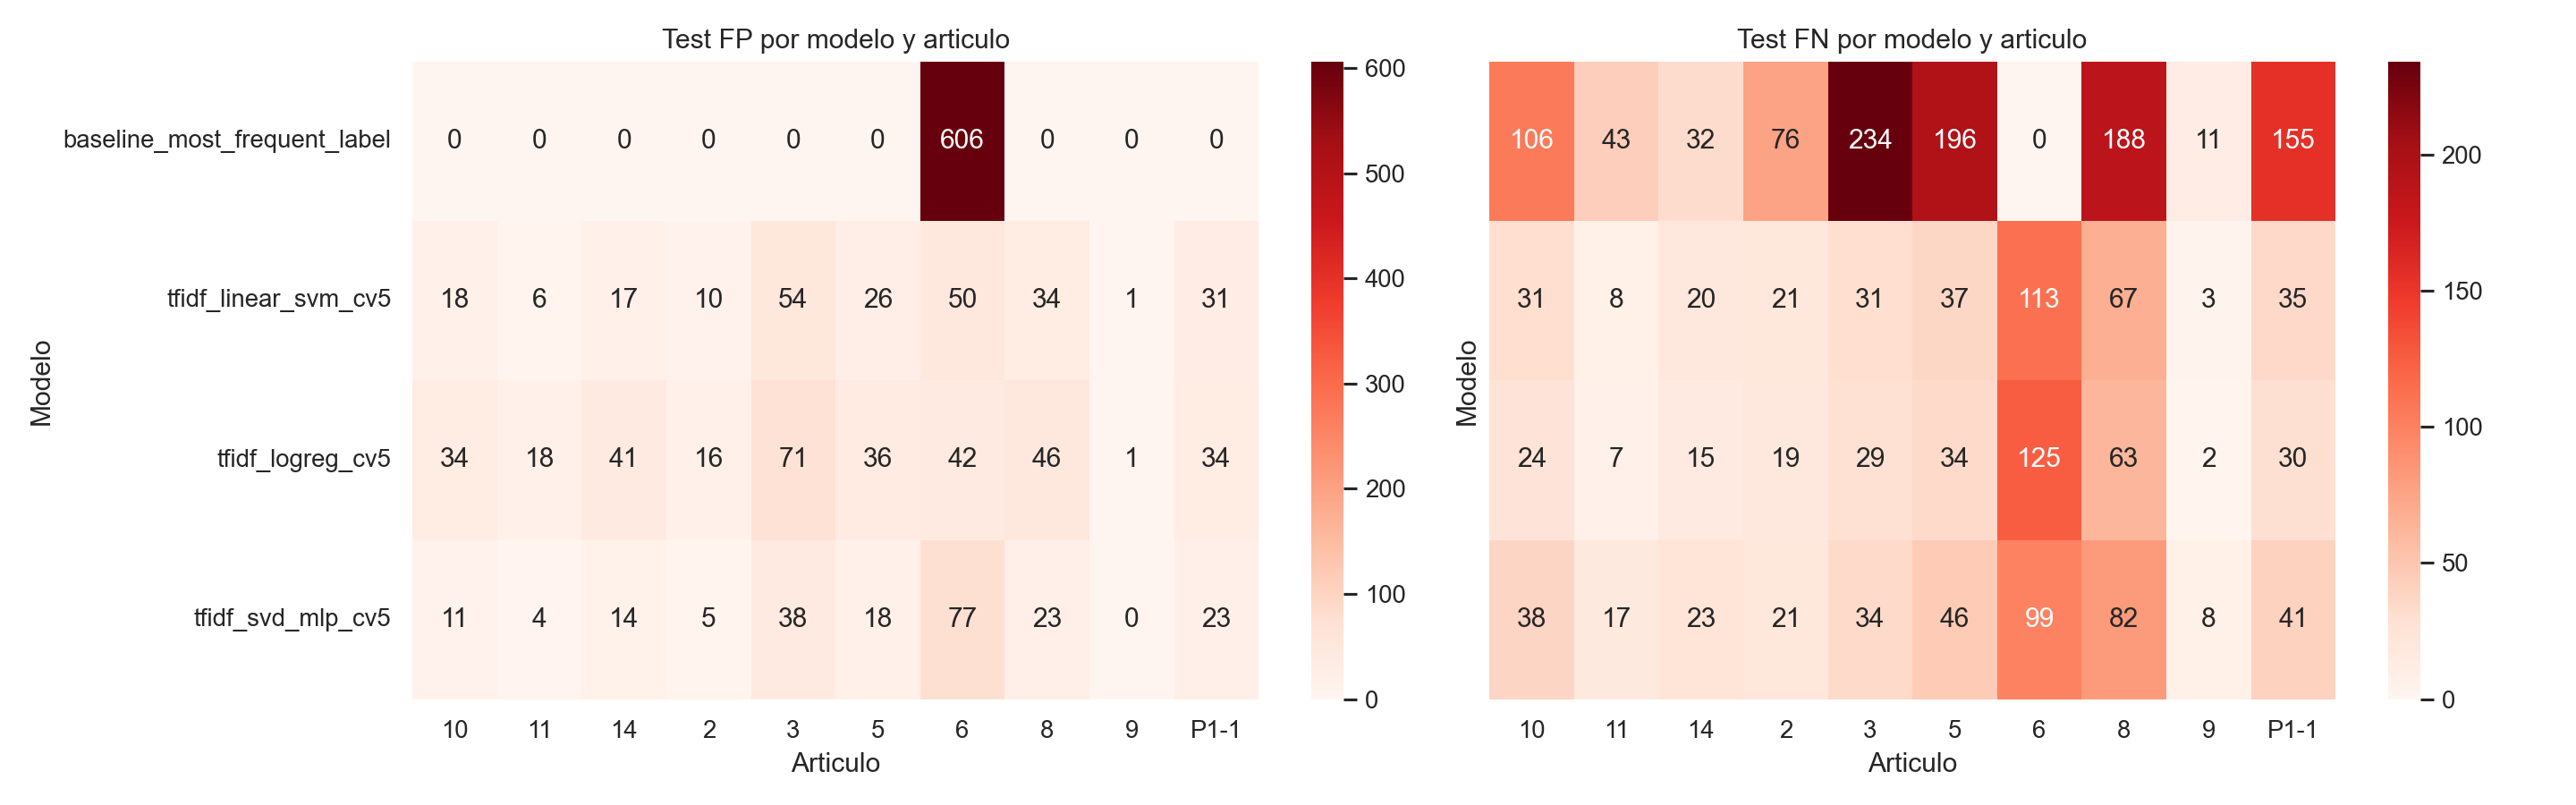

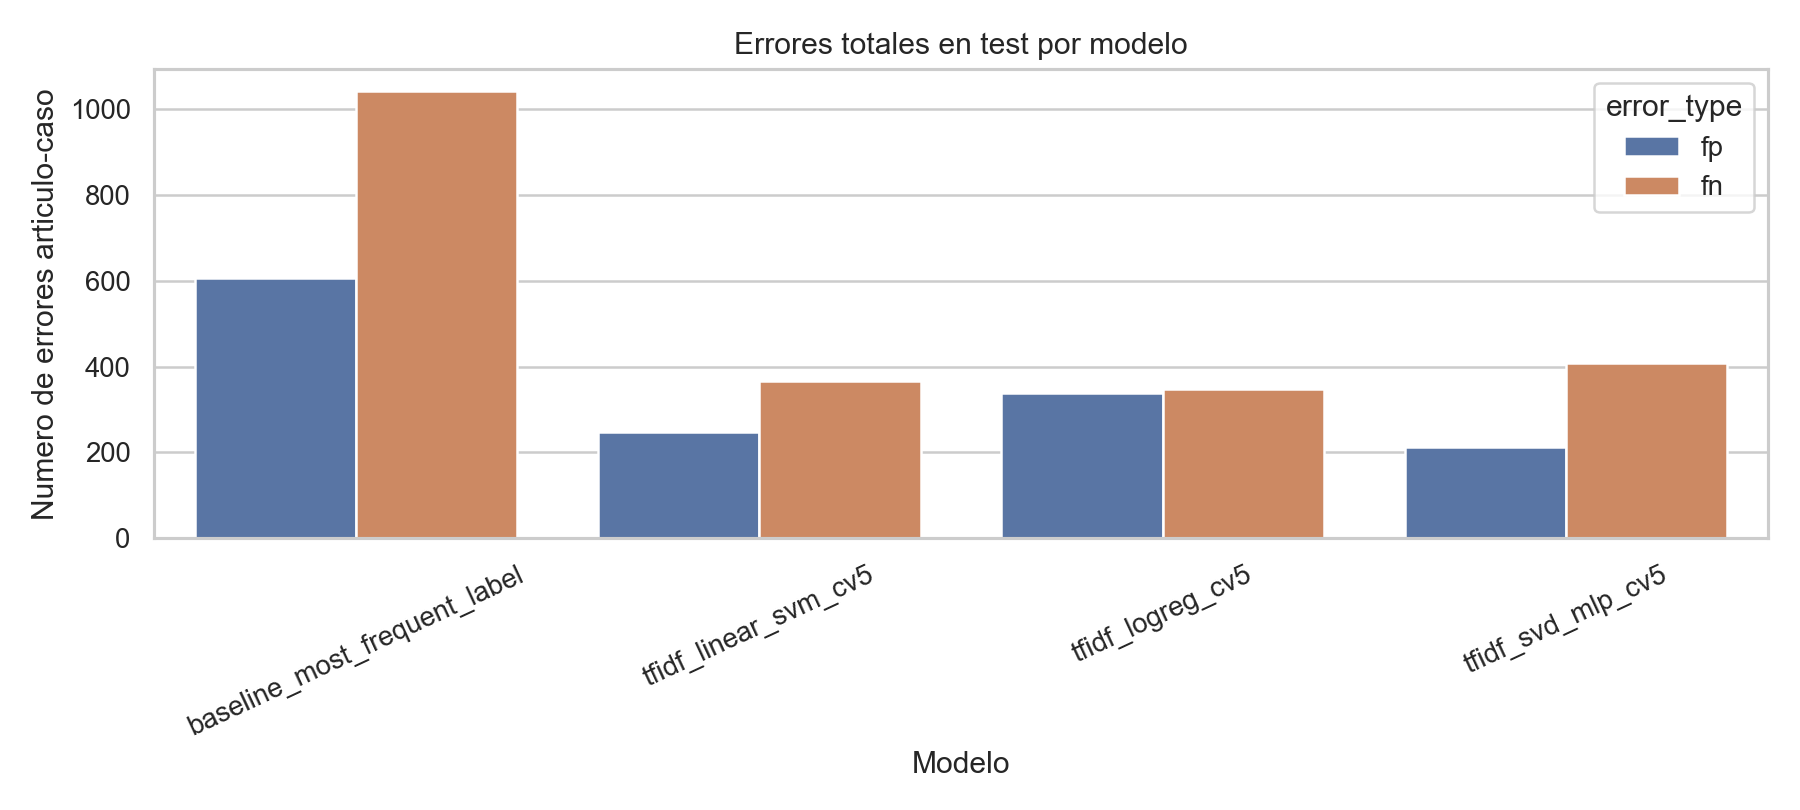

In [19]:
test_comparison = comparison[comparison['split'] == 'test'].sort_values('macro_f1', ascending=False)
display(test_comparison[['model', 'macro_f1', 'micro_f1']])

test_correspondence = pd.concat([
    correspondence_table(arrays['test']['y'], preds['test'], model_name, split='test')
    for model_name, preds in model_predictions.items()
], ignore_index=True)
test_correspondence.to_csv(pu.METRICS / 'classification_test_correspondence_matrix.csv', index=False)

error_heat = test_correspondence.melt(
    id_vars=['model', 'article_code'], value_vars=['fp', 'fn'],
    var_name='error_type', value_name='n_errors'
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, error_type in zip(axes, ['fp', 'fn']):
    pivot = error_heat[error_heat['error_type'] == error_type].pivot(index='model', columns='article_code', values='n_errors')
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title(f'Test {error_type.upper()} por modelo y articulo')
    ax.set_xlabel('Articulo')
    ax.set_ylabel('Modelo')
fig.tight_layout()
figure_path = pu.FIGURES / 'classification_test_error_correspondence.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

error_totals = test_correspondence.groupby('model', as_index=False)[['fp', 'fn']].sum()
error_totals_long = error_totals.melt(id_vars='model', value_vars=['fp', 'fn'], var_name='error_type', value_name='n_errors')
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=error_totals_long, x='model', y='n_errors', hue='error_type', ax=ax)
ax.set_title('Errores totales en test por modelo')
ax.set_xlabel('Modelo')
ax.set_ylabel('Numero de errores articulo-caso')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
figure_path = pu.FIGURES / 'classification_test_error_totals.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

## 5. Curvas ROC y Precision-Recall con Matplotlib

Las curvas se dibujan directamente dentro del notebook con `matplotlib`. Se calculan sobre scores continuos, no sobre etiquetas ya umbralizadas. Por eso se comparan LogReg, SVM y MLP; el baseline constante queda fuera porque no ordena casos por confianza.

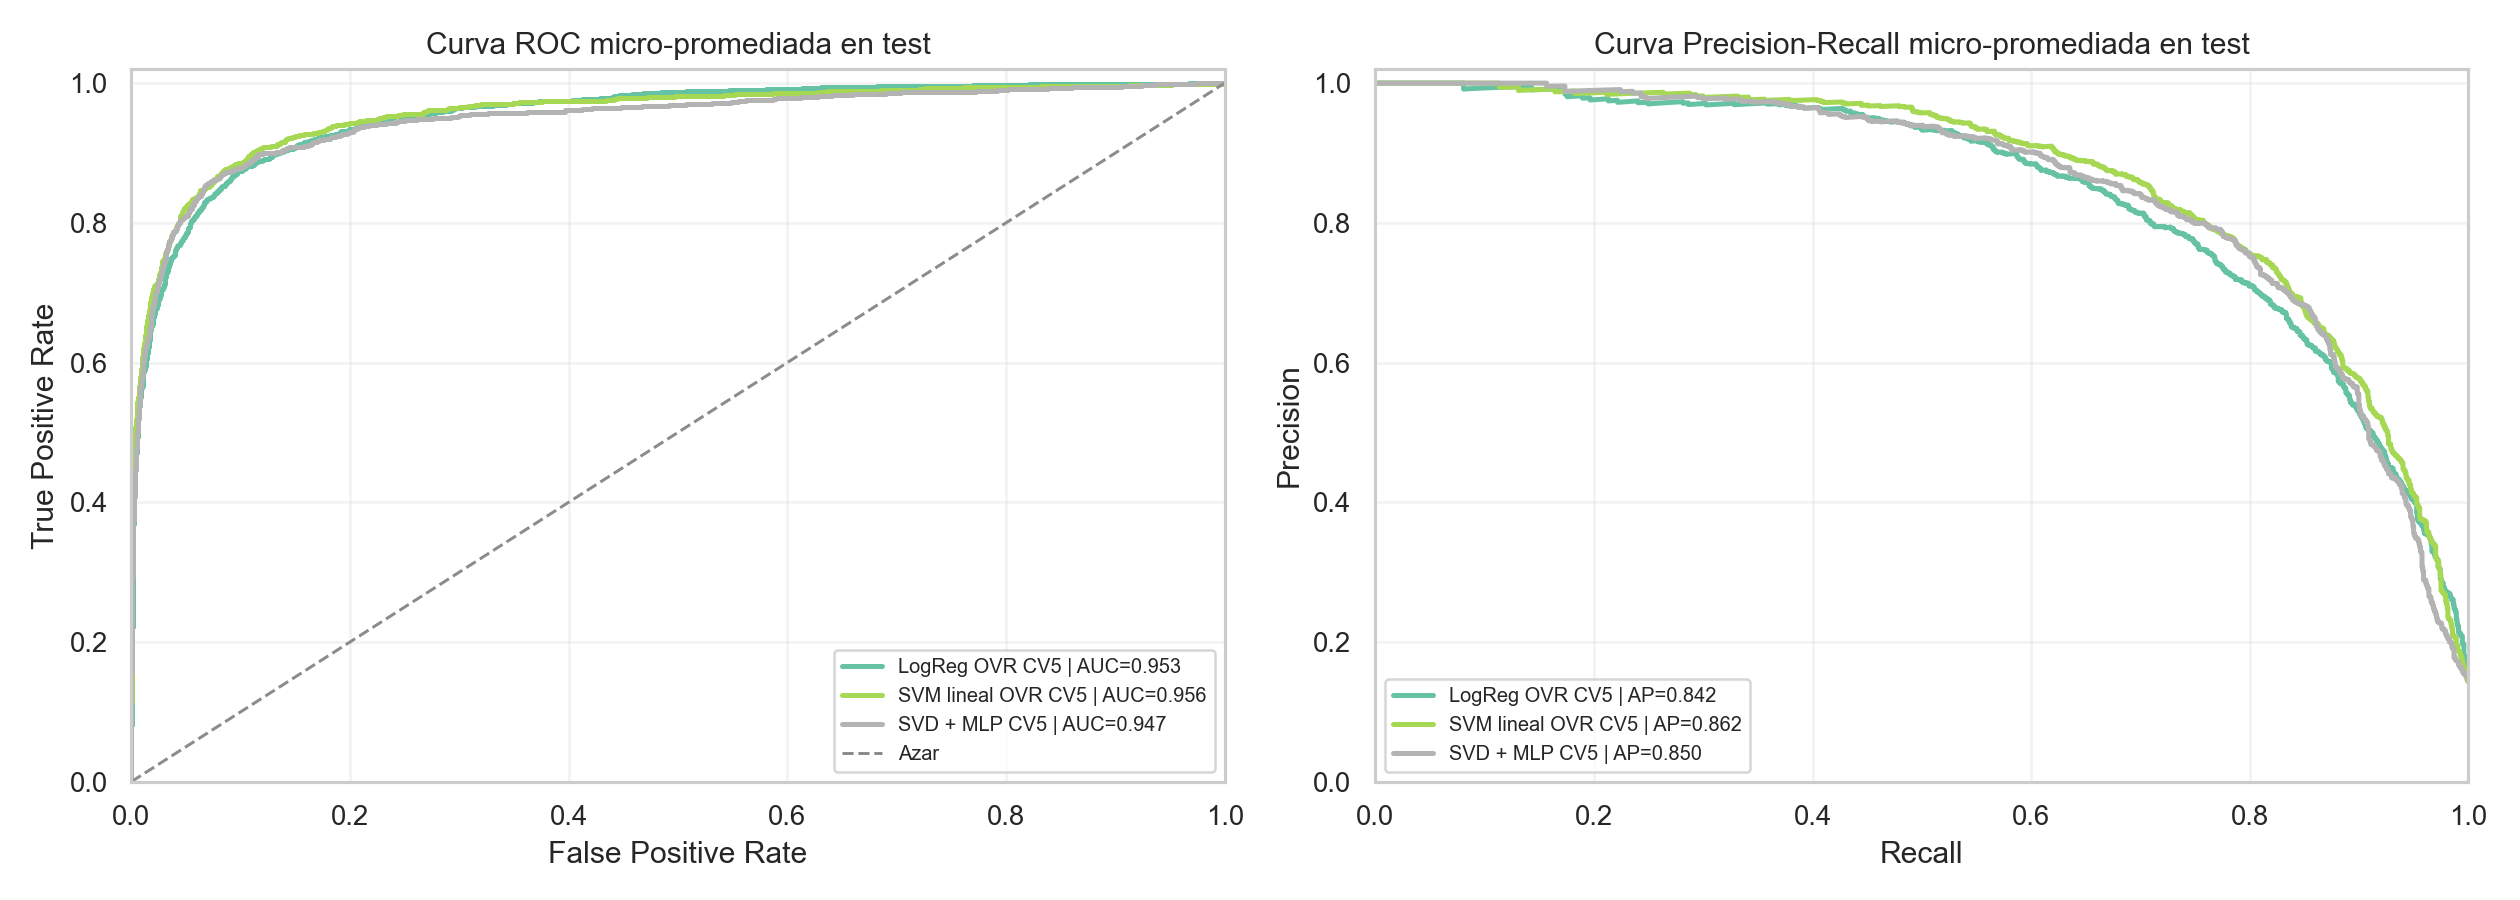

In [20]:
score_models_for_curves = {
    'LogReg OVR CV5': model_scores['tfidf_logreg_cv5']['test'],
    'SVM lineal OVR CV5': model_scores['tfidf_linear_svm_cv5']['test'],
    'SVD + MLP CV5': model_scores['tfidf_svd_mlp_cv5']['test'],
}
y_test = arrays['test']['y']

roc_pr_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(score_models_for_curves)))

for color, (model_name, scores) in zip(colors, score_models_for_curves.items()):
    fpr, tpr, _ = roc_curve(y_test.ravel(), scores.ravel())
    precision, recall, _ = precision_recall_curve(y_test.ravel(), scores.ravel())

    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    roc_pr_rows.append({
        'model': model_name,
        'split': 'test',
        'roc_auc_micro_curve': float(roc_auc),
        'pr_auc_micro_curve': float(pr_auc),
    })

    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} | AUC={roc_auc:.3f}')
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{model_name} | AP={pr_auc:.3f}')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='0.55', linewidth=1.2, label='Azar')
axes[0].set_title('Curva ROC micro-promediada en test')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend(loc='lower right', fontsize=8)

axes[1].set_title('Curva Precision-Recall micro-promediada en test')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)
axes[1].legend(loc='lower left', fontsize=8)

fig.tight_layout()
roc_pr_figure_path = pu.FIGURES / 'classification_test_roc_pr_curves.png'
fig.savefig(roc_pr_figure_path, dpi=180)
plt.close(fig)

display(IPImage(filename=str(roc_pr_figure_path)))

roc_pr_summary = pd.DataFrame(roc_pr_rows)
roc_pr_summary.to_csv(pu.METRICS / 'classification_test_roc_pr_summary.csv', index=False)

## 6. Esquema visual de texto a matrices X/Y

**Lectura del esquema.** Los textos reales entran al vectorizador TF-IDF dentro del pipeline. La matriz `X` tiene filas de casos y columnas de terminos o bigramas.

Las etiquetas reales forman la matriz `Y`. Sus filas son los mismos casos. Sus columnas son articulos. Sus valores son 0 o 1.

El modelo aprende a aproximar `Y` desde `X`. Despues aplica su regla estandar de prediccion para producir decisiones multietiqueta.


## 7. Interpretacion compacta de metricas

En pantalla se priorizan `macro_f1` y `micro_f1`. `macro_f1` detecta fallos en articulos escasos; `micro_f1` resume el rendimiento global. Otras metricas se guardan en CSV y se usan en figuras especificas: ROC/PR para ranking de scores y TP/FP/FN/TN para auditoria de errores.

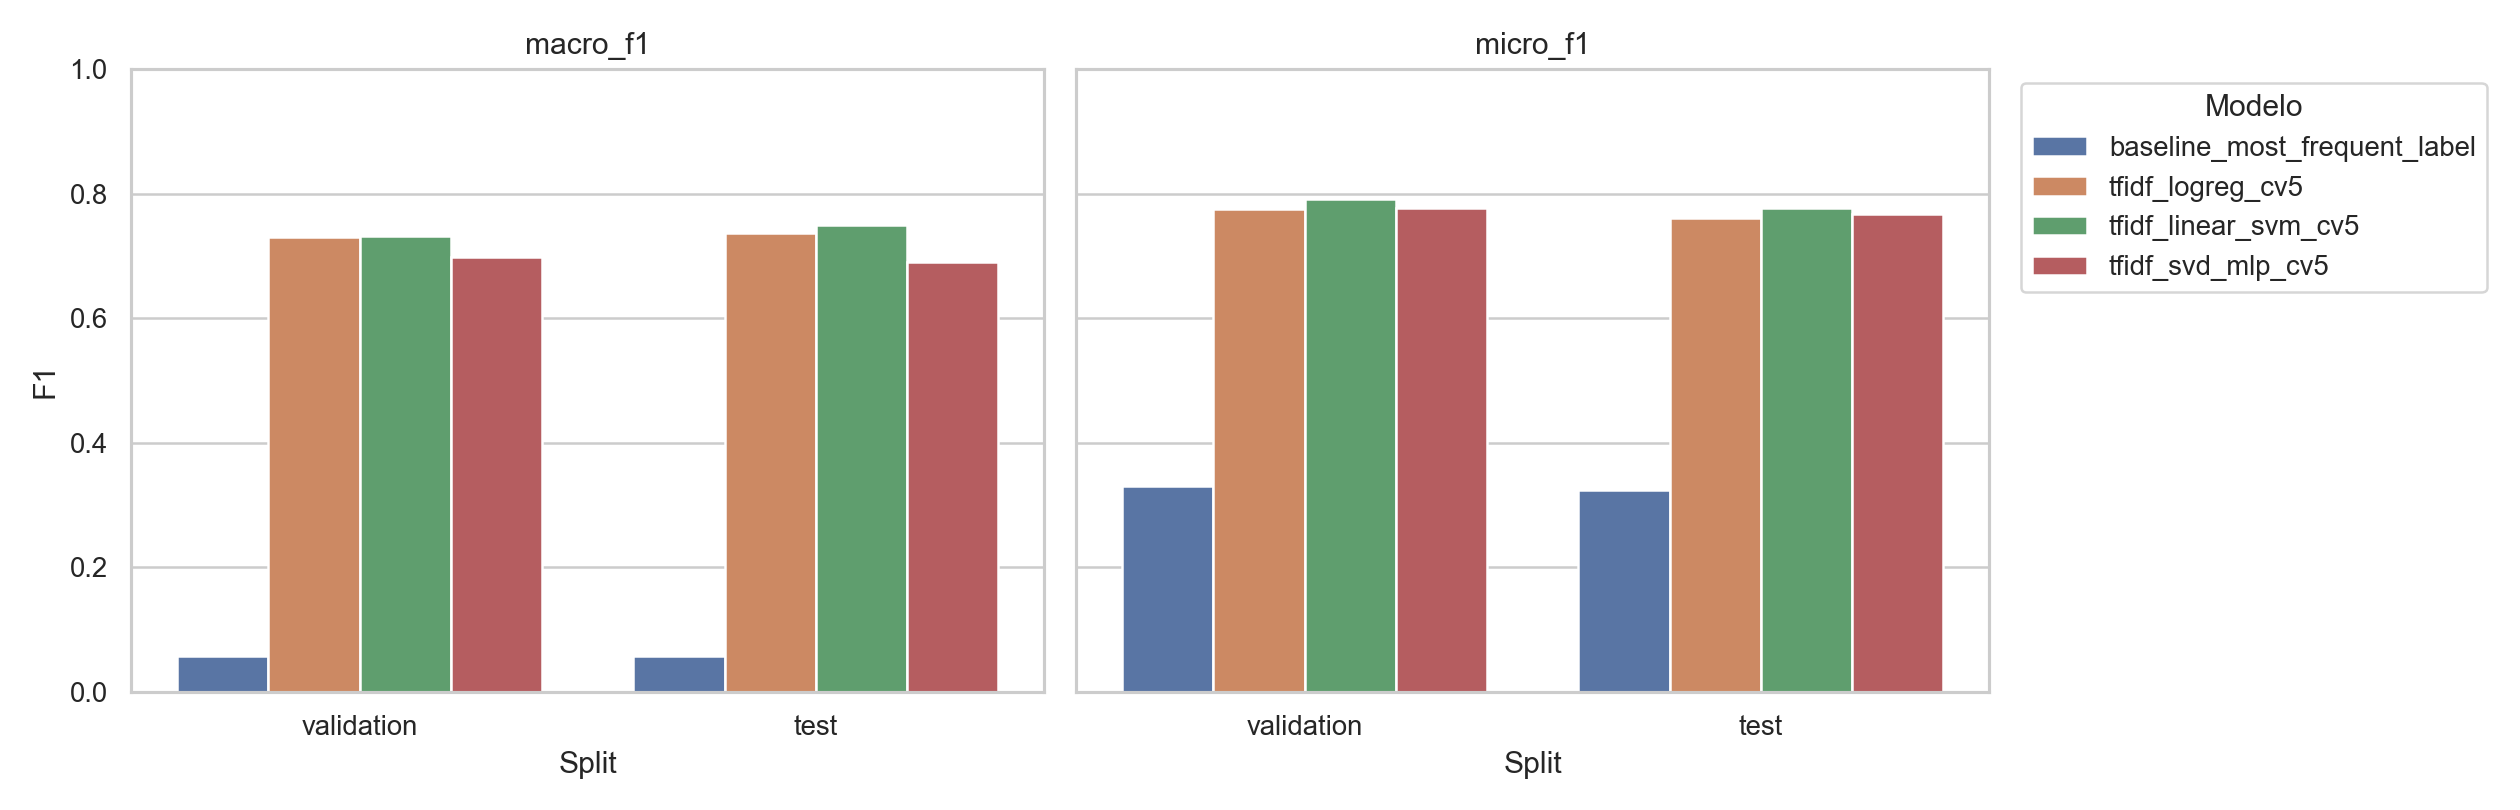

In [21]:
metric_plot_df = comparison[comparison['split'].isin(['validation', 'test'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, metric in zip(axes, ['macro_f1', 'micro_f1']):
    sns.barplot(data=metric_plot_df, x='split', y=metric, hue='model', order=['validation', 'test'], ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('Split')
    ax.set_ylabel('F1')
    ax.set_ylim(0, 1)
axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
figure_path = pu.FIGURES / 'model_comparison_metrics.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

## 8. Ejemplos reales de prediccion

Se leen las predicciones guardadas en SQLite para el modelo auditado. La tabla se mantiene pequena: etiquetas reales, etiquetas predichas y score maximo para casos de test.

In [22]:
pred = pu.load_predictions(RUN_ID)
def decode(row, field):
    return ', '.join([code for code, value in zip(pu.ARTICLE_CODES, row[field]) if value]) or '(ninguno)'
sample = pred[pred['split']=='test'].head(8).copy()
sample['true_articles'] = sample.apply(lambda r: decode(r,'y_true'), axis=1)
sample['pred_articles'] = sample.apply(lambda r: decode(r,'y_pred'), axis=1)
sample['max_score'] = sample['scores'].map(lambda xs: max(xs) if xs else np.nan)
display(sample[['case_id','true_articles','pred_articles','max_score']])
display(pd.DataFrame([pu.summarize_case(sample.iloc[0]['case_id'], max_chars=1000)]))

,case_id,true_articles,pred_articles,max_score
0,ecthr_task_b_test_000000,10,"8, 10",0.960473
1,ecthr_task_b_test_000001,8,"6, 8",0.622794
2,ecthr_task_b_test_000002,6,6,0.672574
3,ecthr_task_b_test_000003,6,6,0.848566
4,ecthr_task_b_test_000004,"3, 6","2, 3",0.976713
5,ecthr_task_b_test_000005,3,"3, 8",0.983514
6,ecthr_task_b_test_000006,6,6,0.602264
7,ecthr_task_b_test_000007,3,3,0.992239


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000000,ecthr_task_b,test,None,37,4774,"5. The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens Næringsliv (“DN”), published by the company DN Nye Medier AS. 6. On 23...",10


## 9. Figura resumen de resultados CV y test


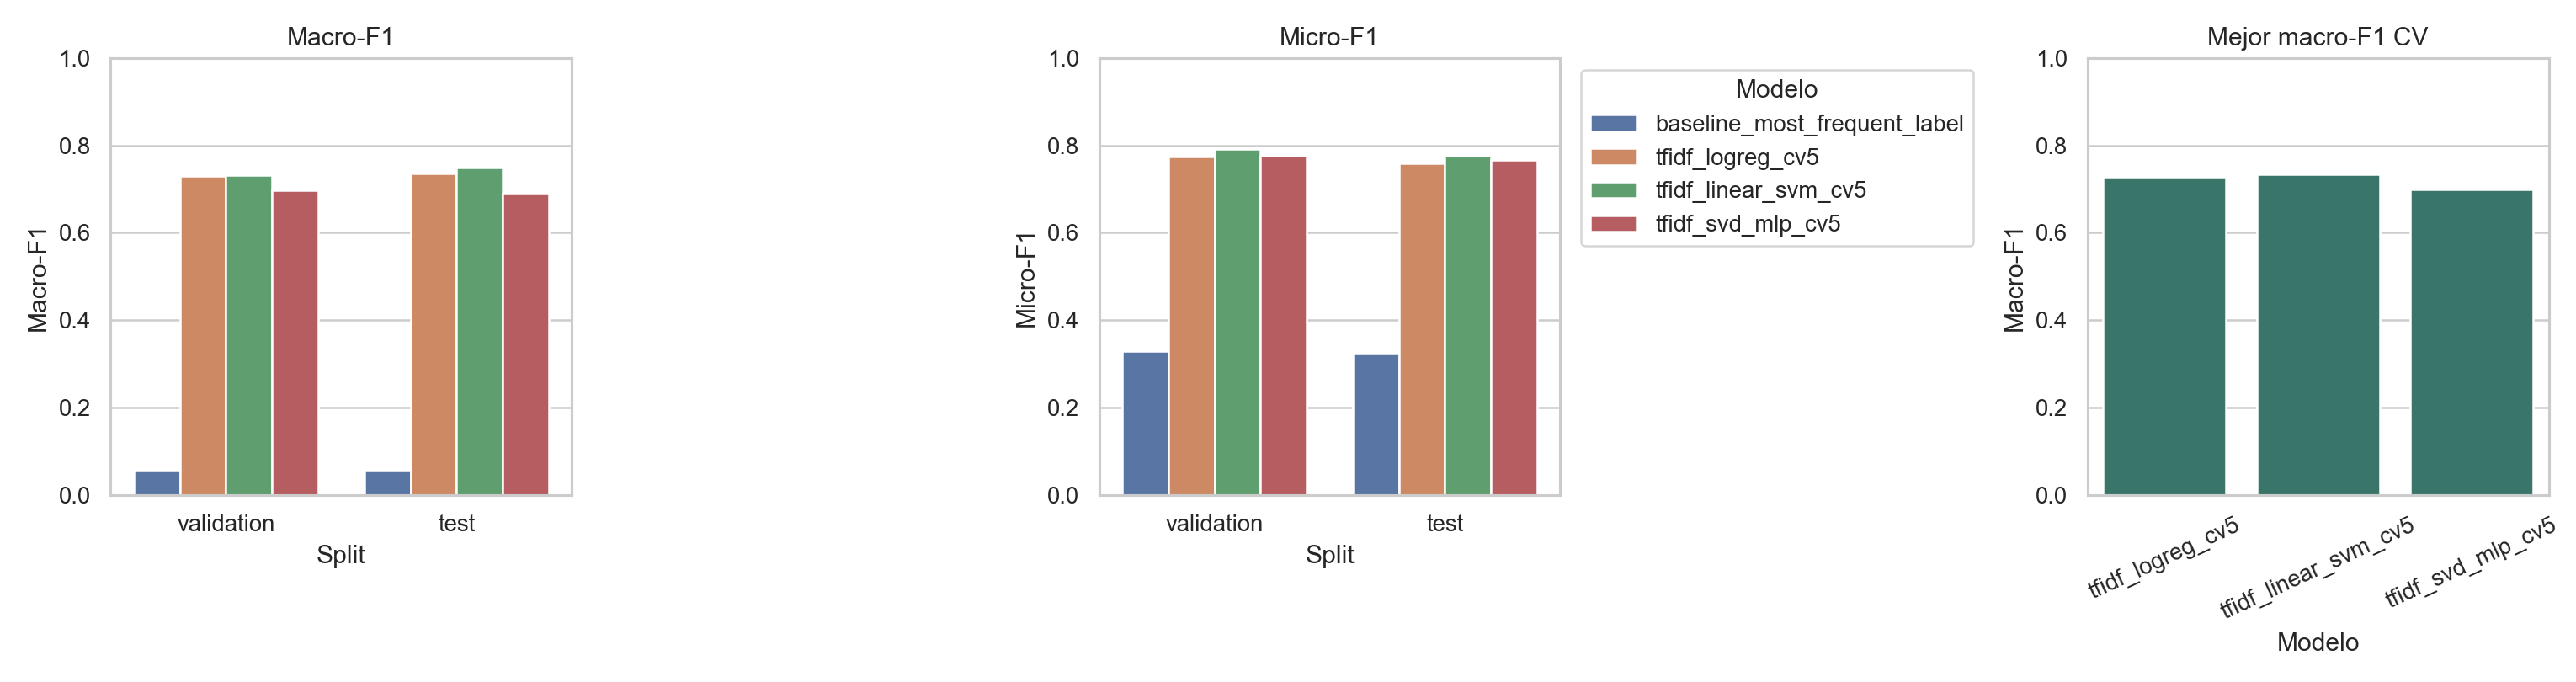

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
plot_df = comparison[comparison['split'].isin(['validation', 'test'])].copy()

sns.barplot(data=plot_df, x='split', y='macro_f1', hue='model', order=['validation', 'test'], ax=axes[0])
axes[0].set_title('Macro-F1')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Macro-F1')

sns.barplot(data=plot_df, x='split', y='micro_f1', hue='model', order=['validation', 'test'], ax=axes[1])
axes[1].set_title('Micro-F1')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Micro-F1')

cv_plot = pd.DataFrame([
    {'model': model_name, 'best_cv_macro_f1': payload.get('best_cv_macro_f1')}
    for model_name, payload in best_params.items()
])
sns.barplot(data=cv_plot, x='model', y='best_cv_macro_f1', ax=axes[2], color='#2f7f6f')
axes[2].set_title('Mejor macro-F1 CV')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Modelo')
axes[2].set_ylabel('Macro-F1')
axes[2].tick_params(axis='x', rotation=25)

axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
figure_path = pu.FIGURES / 'fig04_modeling_and_thresholds.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

## 10. Resultado del notebook

Quedan pipelines finales en `artifacts/models/`.

Quedan tablas completas en `artifacts/metrics/`.

La seleccion de hiperparametros se hace con `GridSearchCV` y 5 folds usando solo train.

Test se usa solo para la evaluacion final.

Las predicciones de la regresion logistica auditada quedan en SQLite para el notebook 04.


## Nota de reproducibilidad

Antes de la entrega final se recomienda ejecutar los notebooks en orden.

Esto regenera salidas y metadatos de ejecucion.
